# Neural Network Baseline Model

SMLP baseline using the 57-feature CLR + presence + engineered feature set.

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


# Load Data

In [2]:
df = pd.read_parquet('../../data/processed/engineered_features_nn.parquet')
print(f'Shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')

Shape: (2294985, 62)
Label distribution:
label
Non_GSR    1216039
GSR        1078946
Name: count, dtype: int64


In [3]:
meta_cols = ['stub_id', 'particle_id', 'label', 'target', 'final_class']
feature_cols = [c for c in df.columns if c not in meta_cols]
print(f'Features: {len(feature_cols)}')

X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
groups = df['stub_id'].values

Features: 57


# Group-Aware Train/Test Split

Using GroupShuffleSplit on stub_id to prevent leakage from particles on the same stub appearing in both train and test.

In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f'Train: {len(train_idx):,} ({y_train.mean():.1%} GSR)')
print(f'Test:  {len(test_idx):,} ({y_test.mean():.1%} GSR)')
print(f'Train stubs: {len(np.unique(groups_train)):,}')
print(f'Test stubs:  {len(np.unique(groups[test_idx])):,}')

Train: 1,851,761 (46.9% GSR)
Test:  443,224 (47.4% GSR)
Train stubs: 3,028
Test stubs:  758


In [6]:
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0, 'Stub leakage!'

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f'Train mean (first 5): {X_train.mean(axis=0)[:5].round(4)}')
print(f'Train std  (first 5): {X_train.std(axis=0)[:5].round(4)}')

Train mean (first 5): [-0. -0.  0. -0. -0.]
Train std  (first 5): [0.9994 0.9992 0.9998 0.9999 1.0004]


# Baseline MLP Architecture

Deliberately simple: 2 hidden layers, 128 units each, ReLU, dropout 0.3. No tuning since this is our baseline/performance floor.

In [8]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.net(x)

model = BaselineMLP(input_dim=len(feature_cols)).to(device)

In [10]:
print(f'\nParameters: {sum(p.numel() for p in model.parameters()):,}')


Parameters: 24,065


# Train

In [11]:
train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=4096, shuffle=False)

In [12]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 10
train_losses = []
test_losses = []

for epoch in range(n_epochs):

    model.train()
    epoch_loss = 0
    n_batches = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb).squeeze()
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_losses.append(epoch_loss / n_batches)
    
    model.eval()
    test_loss = 0
    n_test = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).squeeze()
            test_loss += criterion(logits, yb).item()
            n_test += 1
    test_losses.append(test_loss / n_test)
    
    print(f'Epoch {epoch+1}/{n_epochs}  '
          f'Train Loss: {train_losses[-1]:.4f}  '
          f'Test Loss: {test_losses[-1]:.4f}')

Epoch 1/10  Train Loss: 0.0328  Test Loss: 0.0061
Epoch 2/10  Train Loss: 0.0060  Test Loss: 0.0048
Epoch 3/10  Train Loss: 0.0050  Test Loss: 0.0043
Epoch 4/10  Train Loss: 0.0044  Test Loss: 0.0037
Epoch 5/10  Train Loss: 0.0039  Test Loss: 0.0032
Epoch 6/10  Train Loss: 0.0036  Test Loss: 0.0031
Epoch 7/10  Train Loss: 0.0033  Test Loss: 0.0028
Epoch 8/10  Train Loss: 0.0031  Test Loss: 0.0025
Epoch 9/10  Train Loss: 0.0030  Test Loss: 0.0025
Epoch 10/10  Train Loss: 0.0029  Test Loss: 0.0025


# Check for overfitting 

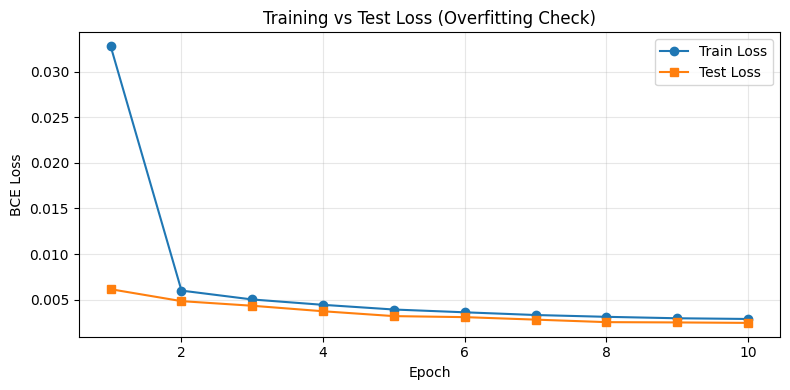

Final train loss: 0.0029
Final test loss:  0.0025
Gap: -0.0004


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_epochs+1), train_losses, label='Train Loss', marker='o')
ax.plot(range(1, n_epochs+1), test_losses, label='Test Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Training vs Test Loss (Overfitting Check)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Final test loss:  {test_losses[-1]:.4f}')
print(f'Gap: {test_losses[-1] - train_losses[-1]:.4f}')

# Evaluation

In [14]:
model.eval()
all_logits = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        all_logits.append(model(xb).squeeze().cpu())

logits_test = torch.cat(all_logits).numpy()
probs_test = 1 / (1 + np.exp(-logits_test))  # sigmoid
preds_test = (probs_test >= 0.5).astype(int)

In [15]:
print('Classification Report (threshold=0.5)')
print(classification_report(y_test, preds_test, target_names=['Non_GSR', 'GSR']))

Classification Report (threshold=0.5)
              precision    recall  f1-score   support

     Non_GSR       1.00      1.00      1.00    233275
         GSR       1.00      1.00      1.00    209949

    accuracy                           1.00    443224
   macro avg       1.00      1.00      1.00    443224
weighted avg       1.00      1.00      1.00    443224



In [17]:
cm = confusion_matrix(y_test, preds_test)
print(f'Confusion Matrix:')
print(f'TN={cm[0,0]:,} FP={cm[0,1]:,}')
print(f'FN={cm[1,0]:,} TP={cm[1,1]:,}')
print(f'\nFalse Positive Rate: {cm[0,1]/(cm[0,0]+cm[0,1]):.4f}')
print(f'False Negative Rate: {cm[1,0]/(cm[1,0]+cm[1,1]):.4f}')

Confusion Matrix:
TN=233,009 FP=266
FN=90 TP=209,859

False Positive Rate: 0.0011
False Negative Rate: 0.0004


In [18]:
roc_auc = roc_auc_score(y_test, probs_test)
pr_auc = average_precision_score(y_test, probs_test)
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC: {pr_auc:.4f}')

ROC-AUC: 1.0000
PR-AUC:  1.0000


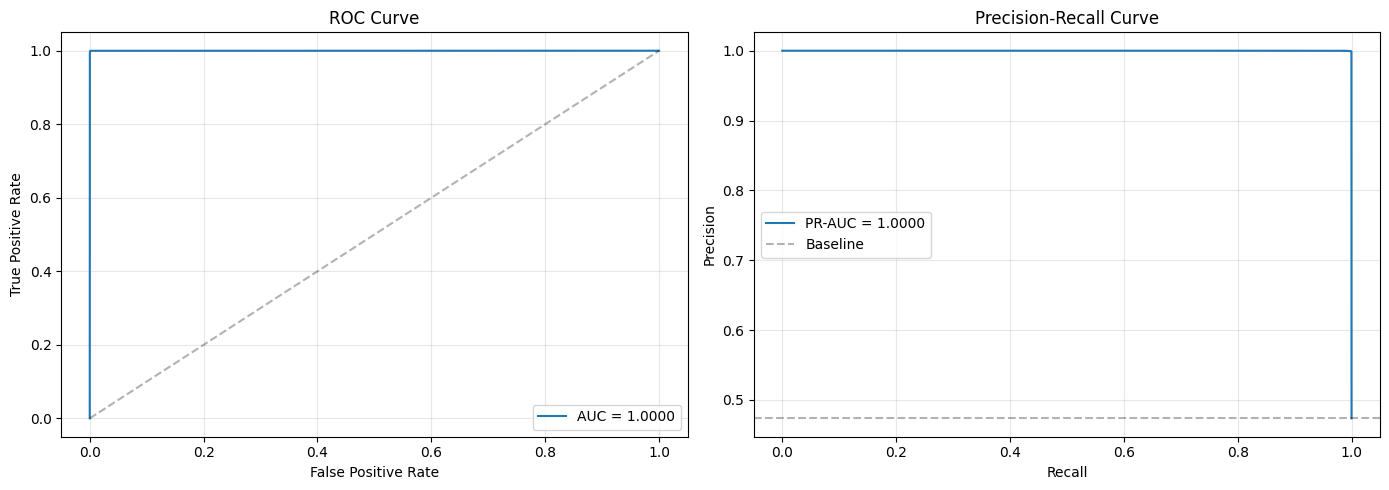

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, probs_test)
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, probs_test)
axes[1].plot(rec, prec, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.3, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-Subclass Performance

In [20]:
test_classes = df['final_class'].values[test_idx]
test_labels = df['label'].values[test_idx]

results = []
for cls in sorted(np.unique(test_classes)):
    mask = test_classes == cls
    n = mask.sum()
    label = test_labels[mask][0]
    if n < 10:
        continue
    cls_preds = preds_test[mask]
    cls_true = y_test[mask]
    acc = (cls_preds == cls_true).mean()
    if label == 'GSR':
        rate = cls_preds.mean()  #predicted GSR rate 
        metric_name = 'Recall'
    else:
        rate = 1 - cls_preds.mean()  #predicted Non-GSR rate 
        metric_name = 'Specificity'
    results.append({'Class': cls, 'Label': label, 'N': n, 
                     'Accuracy': f'{acc:.4f}', metric_name: f'{rate:.4f}'})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Class   Label      N Accuracy Specificity Recall
  BaAl Non_GSR  65221   0.9969      0.9969    NaN
BaCaSi Non_GSR  81503   0.9995      0.9995    NaN
  BaSb     GSR  20708   0.9990         NaN 0.9990
  CuZn Non_GSR  75472   0.9998      0.9998    NaN
GaCuSn Non_GSR    426   1.0000      1.0000    NaN
    Hg Non_GSR    678   0.9941      0.9941    NaN
  PbBa     GSR  48129   0.9985         NaN 0.9985
PbBaSb     GSR 108047   1.0000         NaN 1.0000
  PbSb     GSR  33065   1.0000         NaN 1.0000
TiZnGd Non_GSR   3434   0.9991      0.9991    NaN
  ZnTi Non_GSR   6541   1.0000      1.0000    NaN


# Cross-Val (3-Fold GroupKFold)

In [22]:
def train_and_eval(X_tr, y_tr, X_val, y_val, input_dim, epochs=10, lr=1e-3):
    """Train MLP, return val metrics"""
    mdl = BaselineMLP(input_dim=input_dim).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=lr)
    crit = nn.BCEWithLogitsLoss()
    
    tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                          torch.tensor(y_tr, dtype=torch.float32))
    tr_loader = DataLoader(tr_ds, batch_size=4096, shuffle=True)
    
    for _ in range(epochs):
        mdl.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(mdl(xb).squeeze(), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
    
    mdl.eval()
    with torch.no_grad():
        logits = mdl(torch.tensor(X_val, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    
    return {
        'roc_auc': roc_auc_score(y_val, probs),
        'pr_auc': average_precision_score(y_val, probs),
        'accuracy': (preds == y_val).mean(),
        'fpr': confusion_matrix(y_val, preds)[0,1] / (confusion_matrix(y_val, preds)[0].sum())
    }

In [23]:
gkf = GroupKFold(n_splits=3)
cv_results = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train_raw, y_train, groups_train)):
    sc = StandardScaler()
    X_tr_fold = sc.fit_transform(X_train_raw[tr_idx])
    X_val_fold = sc.transform(X_train_raw[val_idx])
    
    metrics = train_and_eval(X_tr_fold, y_train[tr_idx], 
                              X_val_fold, y_train[val_idx],
                              input_dim=len(feature_cols))
    cv_results.append(metrics)
    
    print(f'Fold {fold+1}: ROC-AUC={metrics["roc_auc"]:.4f}'
          f'PR-AUC={metrics["pr_auc"]:.4f}'
          f'Acc={metrics["accuracy"]:.4f}'
          f'FPR={metrics["fpr"]:.4f}')

print(f'\nMean ROC-AUC: {np.mean([r["roc_auc"] for r in cv_results]):.4f}'
      f'± {np.std([r["roc_auc"] for r in cv_results]):.4f}')
print(f'Mean PR-AUC: {np.mean([r["pr_auc"] for r in cv_results]):.4f}'
      f'± {np.std([r["pr_auc"] for r in cv_results]):.4f}')
print(f'Mean FPR: {np.mean([r["fpr"] for r in cv_results]):.4f}'
      f'± {np.std([r["fpr"] for r in cv_results]):.4f}')

Fold 1: ROC-AUC=1.0000  PR-AUC=1.0000  Acc=0.9990  FPR=0.0016
Fold 2: ROC-AUC=1.0000  PR-AUC=1.0000  Acc=0.9989  FPR=0.0019
Fold 3: ROC-AUC=1.0000  PR-AUC=1.0000  Acc=0.9993  FPR=0.0009

Mean ROC-AUC: 1.0000 ± 0.0000
Mean PR-AUC:  1.0000 ± 0.0000
Mean FPR:     0.0014 ± 0.0004


# Summary stats

In [24]:
print('Baseline MLP Summary')
print(f'Architecture: 57 → 128 → 128 → 1 (dropout=0.3)')
print(f'Optimizer: Adam (lr=1e-3)')
print(f'Loss: BCEWithLogitsLoss')
print(f'Epochs: {n_epochs}')
print(f'Batch size: 4096')
print(f'Split: GroupShuffleSplit (stub_id), 80/20')
print(f'Scaling: StandardScaler (fit on train only)')
print(f'')
print(f'Test ROC-AUC:{roc_auc:.4f}')
print(f'Test PR-AUC:{pr_auc:.4f}')
print(f'Test FPR:{cm[0,1]/(cm[0,0]+cm[0,1]):.4f}')
print(f'Test FNR:{cm[1,0]/(cm[1,0]+cm[1,1]):.4f}')
print(f'CV ROC-AUC:{np.mean([r["roc_auc"] for r in cv_results]):.4f} ± {np.std([r["roc_auc"] for r in cv_results]):.4f}')
print(f'CV PR-AUC:{np.mean([r["pr_auc"] for r in cv_results]):.4f} ± {np.std([r["pr_auc"] for r in cv_results]):.4f}')

Baseline MLP Summary
Architecture: 57 → 128 → 128 → 1 (dropout=0.3)
Optimizer: Adam (lr=1e-3)
Loss: BCEWithLogitsLoss
Epochs: 10
Batch size: 4096
Split: GroupShuffleSplit (stub_id), 80/20
Scaling: StandardScaler (fit on train only)

Test ROC-AUC:1.0000
Test PR-AUC:1.0000
Test FPR:0.0011
Test FNR:0.0004
CV ROC-AUC:1.0000 ± 0.0000
CV PR-AUC:1.0000 ± 0.0000
